# 04 — Patch Extraction

Extracts one 64×64 DAPI patch per nucleus from all datasets.

**Labels:**
- `DMSO` → control
- `AcDep` → actin depolymerized (LatA + CytoD pooled)
- `Blebbi`, `CK666`, `Noco` → kept for multi-class level later

**Output:** `patches.npz` containing:
- `patches` : float32 array of shape `(N, 1, 64, 64)` — normalized DAPI crops
- `labels`  : string array of shape `(N,)` — condition per patch
- `meta`    : string array of shape `(N,)` — filename + nucleus ID for traceability

## Cell 1 — Parameters

In [ ]:
from pathlib import Path

# ── Datasets ──────────────────────────────────────────────────────────────────
# List each dataset as a dict with its image folder and channel indices.

DATASETS = [
    {"image_dir": "", "dapi_ch": 0},

]

OUTPUT_DIR = ""

# ── Patch settings ────────────────────────────────────────────────────────────
PATCH_SIZE    = 64     # output patch size in pixels (both height and width)
PAD_PX        = 10     # extra padding around nucleus bounding box before resize
MIN_NUCLEUS_PX = 200   # discard nuclei smaller than this (same as segmentation)

# ── CellPose ──────────────────────────────────────────────────────────────────
CELLPOSE_DIAMETER       = None
FLOW_THRESHOLD          = 0.4
CELLPROB_THRESHOLD      = 0.0

# ── Label mapping ─────────────────────────────────────────────────────────────
# LatA and CytoD are pooled into a single class 'AcDep' (actin depolymerized).
# All other named conditions are kept as-is.
# Conditions not in this dict will be labelled UNKNOWN and discarded.
LABEL_MAP = {
    "DMSO":   "DMSO",
    "LatA":   "AcDep",
    "CytoD":  "AcDep",
    "Blebbi": "Blebbi",
    "CK666":  "CK666",
    "Noco":   "Noco",
    # NCS, ML1, Y27632 → omitted, too few cells
}

CONDITION_KEYWORDS = list(LABEL_MAP.keys()) + ["NCS", "Y27632", "ML1"]

print("Parameters set ✓")
print(f"Output → {OUTPUT_DIR}")

Parameters set ✓
Output → /Users/giuliaam/Desktop/Newlife/ML_Project/CompoundsData/OutputCP/CNN


## Cell 2 — Imports

In [35]:
import os
import re
import numpy as np
import tifffile as tiff
import matplotlib.pyplot as plt
from pathlib import Path
from skimage.measure import regionprops
from skimage.transform import resize
from cellpose import models

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
print("Imports OK ✓")

Imports OK ✓


## Cell 3 — Helper functions

In [36]:
def extract_condition(filename, keywords):
    """Match filename against keyword list, return condition string."""
    name = os.path.basename(filename)
    for kw in keywords:
        if re.search(re.escape(kw), name, re.IGNORECASE):
            return kw
    return "UNKNOWN"


def extract_channel_plane(img, channel_index):
    """Robustly extract a 2D plane from 2D/3D/4D tif arrays."""
    if img.ndim == 2:
        return img.astype(np.float32)
    if img.ndim == 3:
        if img.shape[0] <= 8:
            return img[channel_index].astype(np.float32)
        return np.max(img, axis=0).astype(np.float32)
    if img.ndim == 4:
        dims = sorted(enumerate(img.shape), key=lambda t: t[1], reverse=True)
        (iy, _), (ix, _) = dims[:2]
        rem = [ax for ax in range(4) if ax not in (iy, ix)]
        a0, a1 = rem
        c_ax = a0 if img.shape[a0] <= 8 else a1
        z_ax = a1 if c_ax == a0 else a0
        arr = np.moveaxis(img, (c_ax, z_ax, iy, ix), (0, 1, 2, 3))
        return np.max(arr[channel_index], axis=0).astype(np.float32)
    raise ValueError(f"Unsupported image shape: {img.shape}")


def normalize_plane(plane):
    """Min-max normalize to [0, 1]."""
    pmin, pmax = plane.min(), plane.max()
    if pmax - pmin < 1e-8:
        return np.zeros_like(plane, dtype=np.float32)
    return ((plane - pmin) / (pmax - pmin)).astype(np.float32)


def crop_nucleus(dapi_plane, rp, pad, patch_size):
    """
    Crop the bounding box of one nucleus from the DAPI image,
    add padding, normalize within the crop, resize to patch_size × patch_size.

    Normalization is done WITHIN the crop so that absolute brightness
    differences between replicates do not affect the patch content.
    The network sees only the spatial pattern of DAPI signal.

    Returns float32 array of shape (patch_size, patch_size).
    """
    h, w = dapi_plane.shape
    r0, c0, r1, c1 = rp.bbox  # bounding box from regionprops

    # Add padding, clamp to image boundaries
    r0 = max(0, r0 - pad)
    c0 = max(0, c0 - pad)
    r1 = min(h, r1 + pad)
    c1 = min(w, c1 + pad)

    crop = dapi_plane[r0:r1, c0:c1].copy()

    # Normalize within this crop
    cmin, cmax = crop.min(), crop.max()
    if cmax - cmin < 1e-8:
        return np.zeros((patch_size, patch_size), dtype=np.float32)
    crop = (crop - cmin) / (cmax - cmin)

    # Resize to fixed patch size (anti_aliasing=True to avoid aliasing artifacts)
    patch = resize(
        crop,
        (patch_size, patch_size),
        anti_aliasing=True,
        preserve_range=True
    ).astype(np.float32)

    return patch


def segment_with_cellpose(dapi_plane, model, diameter, flow_threshold, cellprob_threshold):
    """Run CellPose nuclei model on a normalized DAPI plane."""
    img_norm = normalize_plane(dapi_plane)
    masks, _, _ = model.eval(
        img_norm,
        diameter=diameter,
        channels=[0, 0],
        flow_threshold=flow_threshold,
        cellprob_threshold=cellprob_threshold
    )
    return masks


print("Helper functions defined ✓")

Helper functions defined ✓


## Cell 4 — Extract patches from all datasets

In [37]:
print("Loading CellPose nuclei model...")
cp_model = models.CellposeModel(gpu=True, model_type='nuclei')
print("CellPose loaded ✓\n")

all_patches = []   # each entry: float32 (64, 64)
all_labels  = []   # each entry: mapped label string e.g. 'AcDep'
all_meta    = []   # each entry: 'replicate/filename/nucleus_id' for traceability

for dataset in DATASETS:
    image_dir = dataset["image_dir"]
    dapi_ch   = dataset["dapi_ch"]
    replicate = Path(image_dir).name

    print(f"\n{'='*60}")
    print(f"Dataset: {replicate}  (DAPI ch={dapi_ch})")
    print(f"{'='*60}")

    image_paths = sorted(Path(image_dir).glob("*.tif")) + \
                  sorted(Path(image_dir).glob("*.tiff"))
    image_paths = [p for p in image_paths if OUTPUT_DIR not in str(p)]

    print(f"Found {len(image_paths)} images")

    for img_path in image_paths:
        filename  = img_path.name
        condition = extract_condition(filename, CONDITION_KEYWORDS)

        # Skip conditions with no label mapping
        if condition not in LABEL_MAP:
            print(f"  SKIP (no label): {filename}")
            continue

        label = LABEL_MAP[condition]

        # Load image
        img = tiff.imread(str(img_path))

        try:
            dapi_plane = extract_channel_plane(img, dapi_ch)
        except (IndexError, ValueError) as e:
            print(f"  SKIP (channel error): {filename} — {e}")
            continue

        # CellPose segmentation
        masks = segment_with_cellpose(
            dapi_plane, cp_model,
            CELLPOSE_DIAMETER, FLOW_THRESHOLD, CELLPROB_THRESHOLD
        )
        n_nuclei = int(masks.max())

        if n_nuclei == 0:
            print(f"  SKIP (no nuclei): {filename}")
            continue

        # Extract one patch per nucleus
        props       = regionprops(masks, intensity_image=dapi_plane)
        valid_props = [rp for rp in props if rp.area >= MIN_NUCLEUS_PX]

        n_extracted = 0
        for rp in valid_props:
            patch = crop_nucleus(dapi_plane, rp, PAD_PX, PATCH_SIZE)
            all_patches.append(patch)
            all_labels.append(label)
            all_meta.append(f"{replicate}/{filename}/n{rp.label:04d}")
            n_extracted += 1

        print(f"  {condition:8s} → {label:6s} | {n_extracted} nuclei | {filename}")

print(f"\n{'='*60}")
print(f"Total patches extracted: {len(all_patches)}")

model_type argument is not used in v4.0.1+. Ignoring this argument...


Loading CellPose nuclei model...


channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used


CellPose loaded ✓


Dataset: 241018MaxProj  (DAPI ch=0)
Found 17 images


channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used


...

  DMSO     → DMSO   | 2 nuclei | MAX_HeLa_DMSO2_AP.czi - HeLa_DMSO2_AP.czi #10.tif


channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used


  DMSO     → DMSO   | 2 nuclei | MAX_HeLa_DMSO2_AP.czi - HeLa_DMSO2_AP.czi #11.tif


channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used


  DMSO     → DMSO   | 4 nuclei | MAX_HeLa_DMSO2_AP.czi - HeLa_DMSO2_AP.czi #12.tif
  DMSO     → DMSO   | 2 nuclei | MAX_HeLa_DMSO2_AP.czi - HeLa_DMSO2_AP.czi #13.tif

Total patches extracted: 356


## Cell 5 — Dataset summary

In [38]:
import pandas as pd
from collections import Counter

label_counts = Counter(all_labels)
print("Patches per class:")
for cls, count in sorted(label_counts.items()):
    print(f"  {cls:10s}: {count}")
print(f"\nTotal: {len(all_labels)}")

# Class imbalance warning
counts = list(label_counts.values())
if max(counts) / min(counts) > 3:
    print("\n⚠️  Class imbalance detected (ratio > 3x).")
    print("   → Weighted loss will be applied automatically in 05_cnn_classifier.")

Patches per class:
  AcDep     : 148
  Blebbi    : 50
  CK666     : 30
  DMSO      : 102
  Noco      : 26

Total: 356

⚠️  Class imbalance detected (ratio > 3x).
   → Weighted loss will be applied automatically in 05_cnn_classifier.


## Cell 6 — Visualize random patches per class

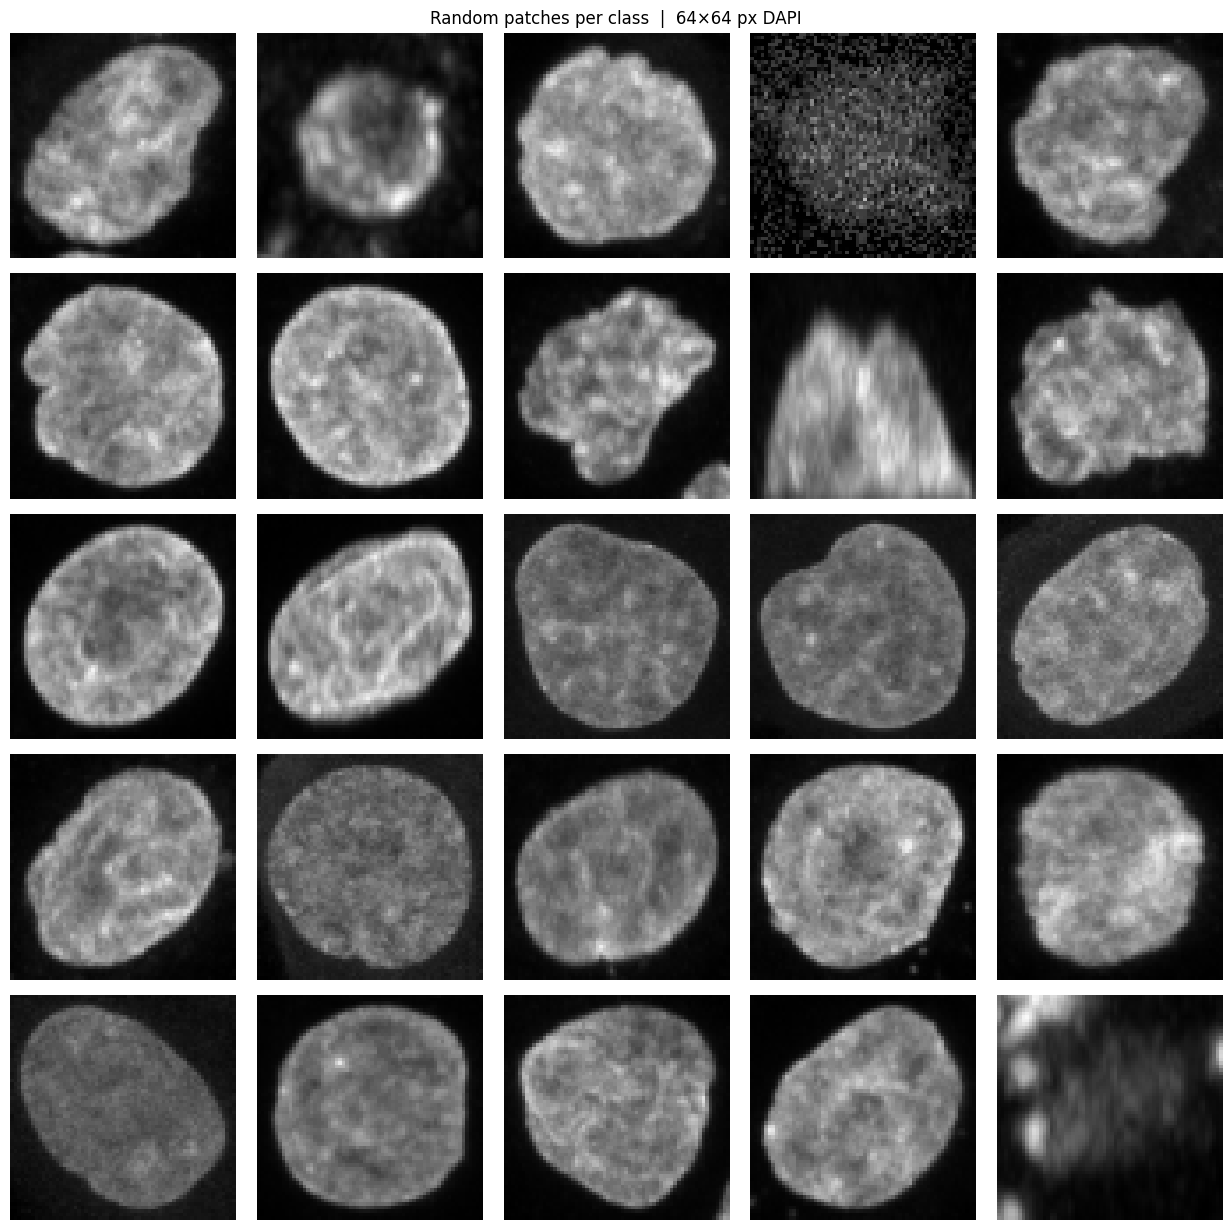

Saved patch_examples.png


In [39]:
labels_arr  = np.array(all_labels)
patches_arr = np.array(all_patches)   # (N, 64, 64)

classes    = sorted(set(all_labels))
n_examples = 5

fig, axes = plt.subplots(len(classes), n_examples, figsize=(n_examples * 2.5, len(classes) * 2.5))

rng = np.random.default_rng(42)

for row, cls in enumerate(classes):
    idx = np.where(labels_arr == cls)[0]
    chosen = rng.choice(idx, size=min(n_examples, len(idx)), replace=False)
    for col, i in enumerate(chosen):
        axes[row, col].imshow(patches_arr[i], cmap='gray', vmin=0, vmax=1)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(cls, fontsize=11, rotation=0, labelpad=45, va='center')

plt.suptitle(f"Random patches per class  |  {PATCH_SIZE}×{PATCH_SIZE} px DAPI", fontsize=12)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/patch_examples.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved patch_examples.png")

## Cell 7 — Save dataset

In [40]:
# Stack patches → (N, 1, 64, 64)  ← channel dimension added here
# The CNN expects input shape (batch, channels, height, width)
patches_final = np.stack(all_patches, axis=0)[:, np.newaxis, :, :]   # (N, 1, 64, 64)
labels_final  = np.array(all_labels)    # (N,) string array
meta_final    = np.array(all_meta)      # (N,) string array

out_path = Path(OUTPUT_DIR) / "patches.npz"
np.savez(
    str(out_path),
    patches=patches_final,
    labels=labels_final,
    meta=meta_final
)

print(f"Saved: {out_path}")
print(f"  patches shape : {patches_final.shape}")
print(f"  labels shape  : {labels_final.shape}")
print(f"  dtype         : {patches_final.dtype}")
print(f"  value range   : [{patches_final.min():.3f}, {patches_final.max():.3f}]")

Saved: /Users/giuliaam/Desktop/Newlife/ML_Project/CompoundsData/OutputCP/CNN/patches.npz
  patches shape : (356, 1, 64, 64)
  labels shape  : (356,)
  dtype         : float32
  value range   : [0.000, 0.998]
